In [11]:
import numpy as np
import matplotlib.pyplot as plt
from S01_pulser import pulser1, pulser2

# Transmission Line

### Transmission Line (T3, T4)
Ideal (lossless); nanowires operate on timescales where current flow has a delay (Td)
### Resistor (R4, R11)
In series; originates at the end of T3, contributes enough resistance to counter the characteristic impedance of T3 prevent reflection of input current. Goes to ground.

In [12]:
# Fixed quantities for transmission lines and associated resistor
Td = 5e-9
Z0 = 50  
RP = 50

### Ohm's law: current law at the arrival of the pulser's current trace at the R4-R5 node (node A)
$$I_{source}(t) = \frac{V_1(t)}{R_P}$$

### Voltage delay: trapezoidal trace arrives at node A after the transmission line delay 
$$V_A(t) = V_1(t - T_d)$$


In [13]:
t = np.linspace(0, 30e-9, 2000)   # (tmin, tmax, number of points in trace)

current_pulser_1 = pulser1(t) / RP          # near-end current
current_pulser_2 = pulser2(t) / RP          

v_farend_1 = pulser1(t - Td)                
v_farend_2 = pulser2(t - Td)  

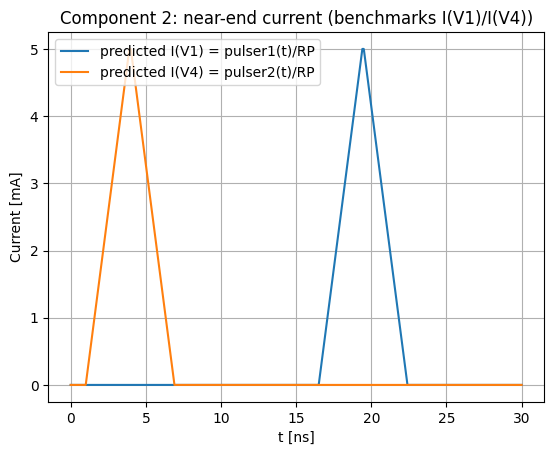

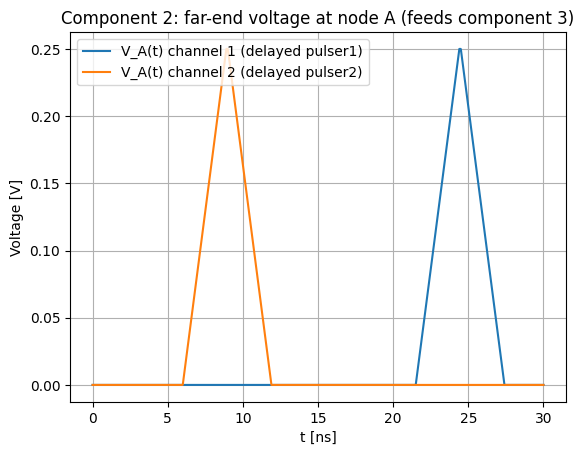

In [14]:
fig, ax = plt.subplots()
ax.plot(t * 1e9, current_pulser_1 * 1e3, label="predicted I(V1) = pulser1(t)/RP")
ax.plot(t * 1e9, current_pulser_2 * 1e3, label="predicted I(V4) = pulser2(t)/RP")
ax.set_xlabel("t [ns]")
ax.set_ylabel("Current [mA]")
ax.set_title("Component 2: near-end current (benchmarks I(V1)/I(V4))")
ax.legend()
ax.grid(True)
plt.show()

fig, ax = plt.subplots()
ax.plot(t * 1e9, v_farend_1, label="V_A(t) channel 1 (delayed pulser1)")
ax.plot(t * 1e9, v_farend_2, label="V_A(t) channel 2 (delayed pulser2)")
ax.set_xlabel("t [ns]")
ax.set_ylabel("Voltage [V]")
ax.set_title("Component 2: far-end voltage at node A (feeds component 3)")
ax.legend()
ax.grid(True)
plt.show()